# Step 8: Run YOLOv8n OBB 
Run locally in the other notebook, or remotely on the Google Colab runtime GPU. Local will take appr. 5 hours. Google GPU 15 min. On the google colab the files are taken from the Google Drive, so it has to be mounted there 

## YOLO pipeline on remote google colab GPU

In [1]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.0 MB/s eta 0:00:00


In [15]:
import os

from google.colab import drive
drive.mount('/content/drive')

# Check current working directory
print(f"Current Directory: {os.getcwd()}")
print(os.listdir(os.getcwd()))
# Define your yaml path
yaml_path = '/content/drive/MyDrive/project_yolo_obb/data.yaml'

if os.path.exists(yaml_path):
    print(f"✅ Found it! Path is correct: {os.path.abspath(yaml_path)}")
else:
    print(f"❌ Cannot find {yaml_path}")
    print("Contents of 'data' folder:")
    if os.path.exists('data'):
        print(os.listdir(os.getcwd()))
    else:
        print("'data' folder itself is missing!")

Mounted at /content/drive
Current Directory: /content
['.config', 'drive', 'yolov8n-obb.pt', 'runs', 'sample_data']
✅ Found it! Path is correct: /content/drive/MyDrive/project_yolo_obb/data.yaml


In [2]:
import torch

if torch.cuda.is_available():
    print("CUDA is available! Using GPU.")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA device count: {torch.cuda.device_count()}")
    device_param = 0 # Or 'cuda'
else:
    print("CUDA is not available. Using CPU.")
    device_param = 'cpu'

print(f"You should use `device={device_param}` in your model training.")

CUDA is available! Using GPU.
CUDA device name: Tesla T4
CUDA device count: 1
You should use `device=0` in your model training.


In [19]:
from ultralytics import YOLO
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Load the OBB Model
model = YOLO('yolov8n-obb.pt') 

# 2. Train
# If on Mac, device='mps'. If Windows/Linux with GPU, device=0.
model.train(
    data='/content/drive/MyDrive/project_yolo_obb', 
    epochs=100, 
    imgsz=640, 
    batch=16, 
    device=0, 
    degrees=180, # Crucial for fanned symbols
    workers=8,  # <--- Add this! 
    cache=True  # <--- This loads the whole dataset into RAM (if it fits)
)


Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project_yolo_obb, degrees=180, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

ultralytics.utils.metrics.OBBMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cbb501b5df0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,


image 1/1 /content/drive/MyDrive/project_yolo_obb/val/images/4.jpg: 640x480 227 trebles, 73 ensemble_chains, 75.2ms
Speed: 3.6ms preprocess, 75.2ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 480)


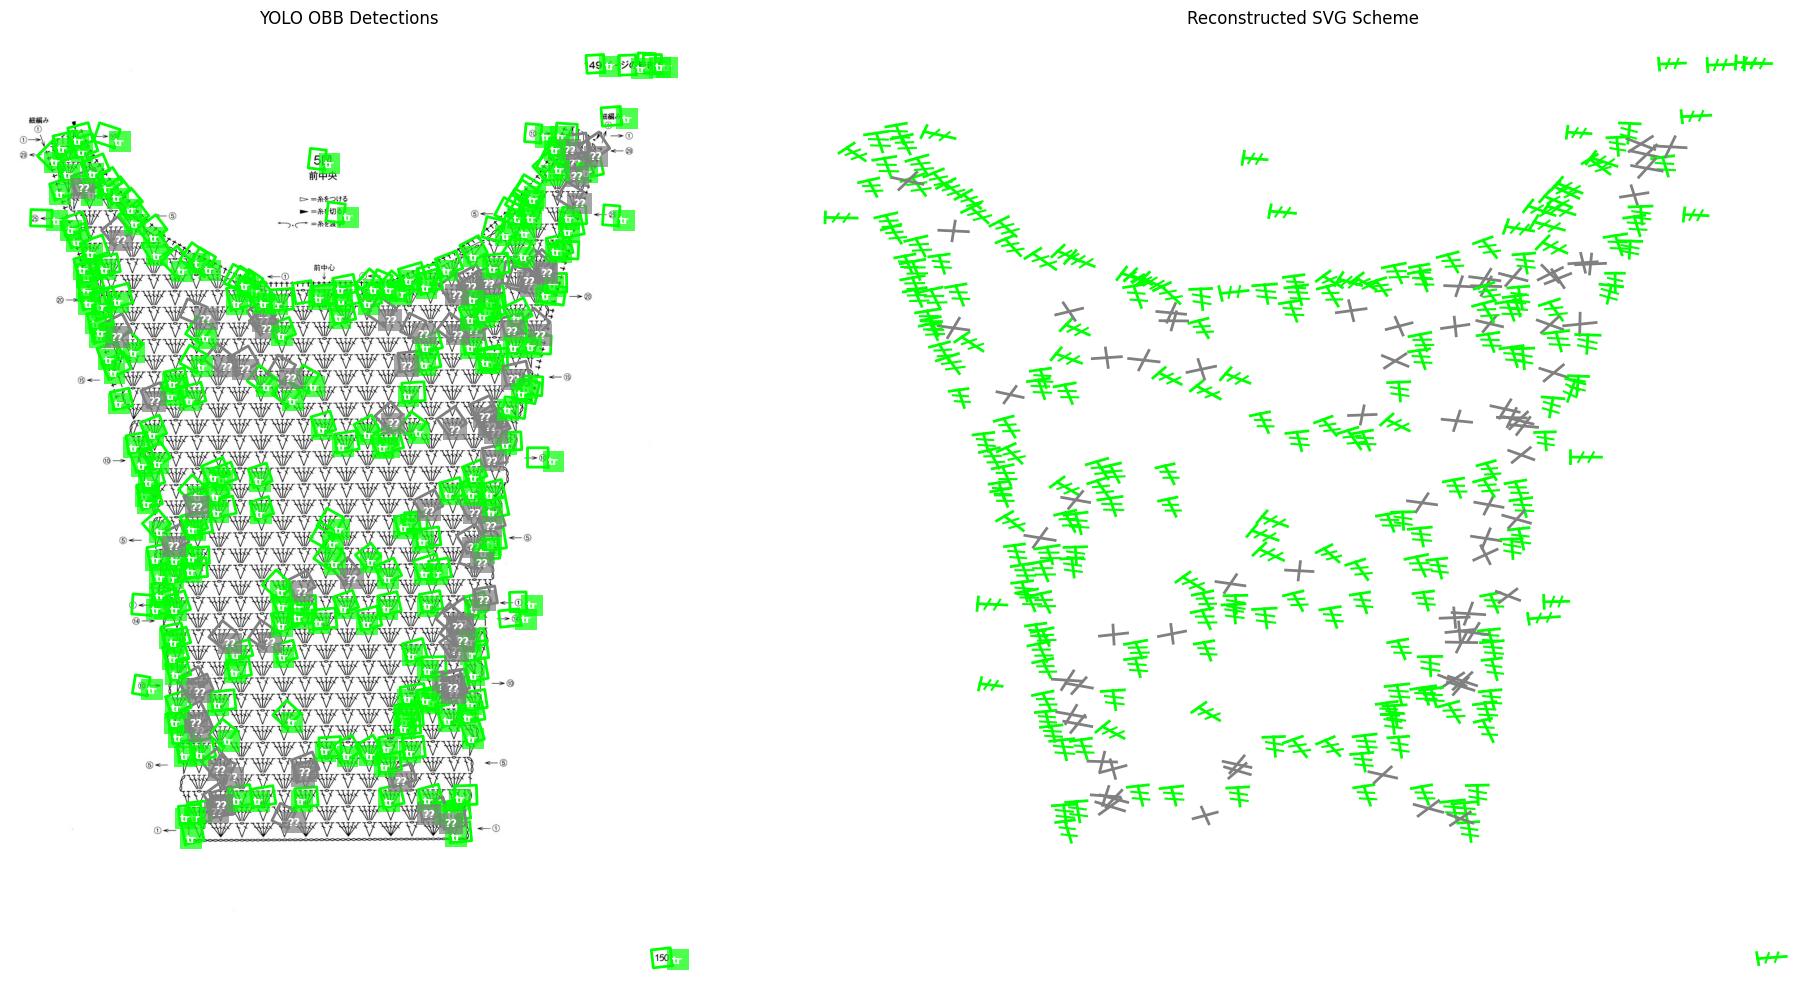

In [25]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import matplotlib.transforms as transforms
from ultralytics import YOLO

# 1. Configuration: Abbreviations and Colors
CLASS_CONFIG = {
    "treble":      {"abbr": "tr", "color": "#00FF00"}, 
    "double":      {"abbr": "dc", "color": "#FF00FF"}, 
    "half_double": {"abbr": "hd", "color": "#00FFFF"}, 
    "chain":       {"abbr": "ch", "color": "#0000FF"}, 
    "single":      {"abbr": "sc", "color": "#FFD700"}, 
    "slip_stitch": {"abbr": "sl", "color": "#FF8000"}, 
    "fan":         {"abbr": "fa", "color": "#FF0000"},
}
DEFAULT_COLOR = "#808080"

# 2. SVG Icon Drawing Logic (FIXED rotate_deg_around)
def draw_svg_icon(ax, label, x, y, w, h, angle_deg, color):
    """Draws geometric crochet symbols using Matplotlib."""
    # Create the transform: Rotate around the center (x, y) then link to plot axes
    t = transforms.Affine2D().rotate_deg_around(x, y, angle_deg) + ax.transData
    
    if label == "chain":
        # Chain is an oval
        icon = patches.Ellipse((x, y), w*0.8, h*0.4, fill=False, color=color, linewidth=2, transform=t)
        ax.add_patch(icon)
    
    elif label in ["half_double", "double", "treble", "fan"]:
        # Vertical Stem
        ax.plot([x, x], [y-h/2, y+h/2], color=color, lw=2, transform=t)
        # Top Horizontal T-bar
        ax.plot([x-w/3, x+w/3], [y-h/2, y-h/2], color=color, lw=2, transform=t)
        
        if label == "double":
            # One angled bar
            ax.plot([x-w/4, x+w/4], [y-h/8, y+h/8], color=color, lw=1.5, transform=t)
        elif label == "treble":
            # Two angled bars
            ax.plot([x-w/4, x+w/4], [y-h/4, y-h/12], color=color, lw=1.5, transform=t)
            ax.plot([x-w/4, x+w/4], [y+h/12, y+h/4], color=color, lw=1.5, transform=t)
        elif label == "fan":
            # Extra angled stems to represent a fan
            ax.plot([x, x-w/3], [y+h/2, y-h/2], color=color, lw=1.5, transform=t, alpha=0.6)
            ax.plot([x, x+w/3], [y+h/2, y-h/2], color=color, lw=1.5, transform=t, alpha=0.6)

    else: 
        # Default 'X' for single crochet or unknown
        ax.plot([x-w/3, x+w/3], [y-h/3, y+h/3], color=color, lw=2, transform=t)
        ax.plot([x-w/3, x+w/3], [y+h/3, y-h/3], color=color, lw=2, transform=t)

# 3. Main Execution
trained_model = YOLO('runs/obb/train11/weights/best.pt')
test_img_path = "/content/drive/MyDrive/project_yolo_obb/val/images/4.jpg"
results = trained_model.predict(test_img_path, conf=0.25)
res = results[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Ax1: Detection Boxes
img_rgb = cv.cvtColor(res.orig_img, cv.COLOR_BGR2RGB)
ax1.imshow(img_rgb)
ax1.set_title("YOLO OBB Detections")

# Ax2: Clean SVG Reconstruction
ax2.set_facecolor('white')
ax2.set_xlim(0, res.orig_img.shape[1])
ax2.set_ylim(res.orig_img.shape[0], 0) # Maintain image coordinate system
ax2.set_title("Reconstructed SVG Scheme")

if len(res.obb) > 0:
    for box in res.obb:
        # xyxyxyxy shape is (1, 4, 2)
        corners = box.xyxyxyxy.cpu().numpy().reshape(4, 2)
        cls_id = int(box.cls[0])
        full_name = res.names[cls_id]
        
        config = CLASS_CONFIG.get(full_name, {"abbr": "??", "color": DEFAULT_COLOR})
        color = config["color"]
        abbr = config["abbr"]

        # --- Ax1 Drawing ---
        closed_corners = np.vstack([corners, corners[0]])
        ax1.plot(closed_corners[:, 0], closed_corners[:, 1], color=color, linewidth=2)
        ax1.text(corners[0, 0], corners[0, 1] - 5, abbr, color='white', fontsize=8, 
                 fontweight='bold', bbox=dict(facecolor=color, edgecolor='none', alpha=0.7))

        # --- Ax2 Drawing Logic ---
        center = corners.mean(axis=0)
        width = np.linalg.norm(corners[0] - corners[1])
        height = np.linalg.norm(corners[0] - corners[3])
        
        # Calculate angle (the angle of the top/bottom edge)
        angle = np.degrees(np.arctan2(corners[1, 1] - corners[0, 1], corners[1, 0] - corners[0, 0]))
        
        draw_svg_icon(ax2, full_name, center[0], center[1], width, height, angle, color)

ax1.axis('off')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [26]:
from google.colab import runtime
runtime.unassign()